#E-Commerce Shipping Analysis: Predictive Modeling

#Step 1: Environment Setup
##We begin by importing the essential libraries. We use Pandas for data handling, Matplotlib and Seaborn for visualization, and Scikit-Learn alongside XGBoost for our machine learning pipeline.

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Step 2: Data Acquisition
In this section, we extract the dataset from its compressed format and load it into a DataFrame. This allows us to inspect the raw features such as customer ratings, costs, and shipping weights.

In [46]:
import zipfile

with zipfile.ZipFile('/content/archive (1).zip','r') as zip_ref:
  zip_ref.extractall('first_zip')

#Step 3: Initial Data Quality Audit
Before processing, we must verify the "health" of our dataset. This code performs two critical checks to ensure the data is model-ready:

Missing Value Detection: Identifying nullentries that could cause mathematical errors.

Schema Inspection: Checking dtypesto confirm that numerical and categorical features are correctly recognized.

In [47]:
import pandas as pd
df = pd.read_csv('/content/first_zip/Train.csv')
print(df.isnull().sum())
print(df.dtypes)

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64
ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object


#Step 4: Categorical Distribution Analysis
We utilize frequency-based count plots to visualize the relationship between logistical categories and delivery success. By comparing Mode of Shipment and Warehouse Blocks , we can identify which operational sectors are most prone to delays.

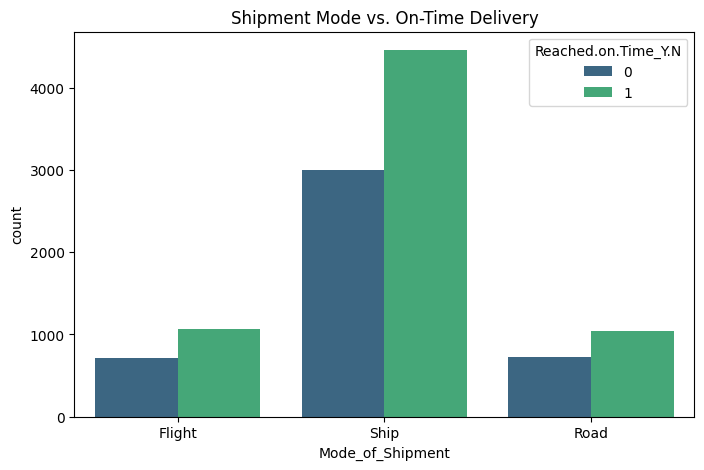

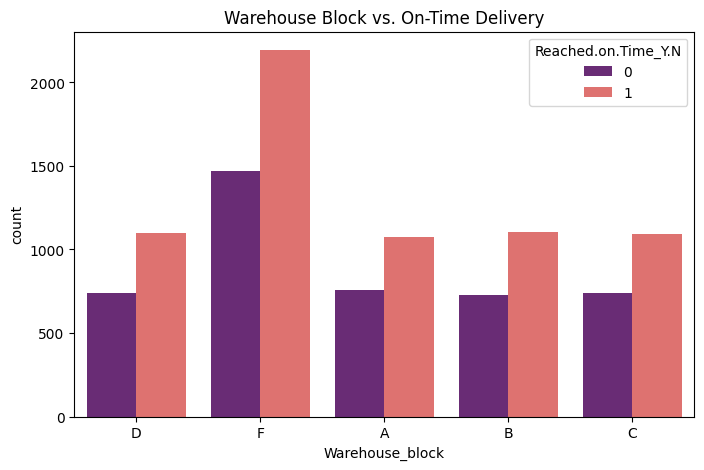

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Mode_of_Shipment', hue='Reached.on.Time_Y.N', palette='viridis')
plt.title('Shipment Mode vs. On-Time Delivery')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Warehouse_block', hue='Reached.on.Time_Y.N', palette='magma')
plt.title('Warehouse Block vs. On-Time Delivery')
plt.show()

#Step 5: Feature Selection & Index Refinement
We remove the IDcolumn from the dataset to ensure model integrity. Since the ID is a unique identifier assigned to each row, it contains no predictive signal and can mislead the model into finding patterns in random noise.


In [49]:
df.drop('ID',axis = 1 , inplace = True)

In [50]:
print(df.head())

  Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0               D           Flight                    4                2   
1               F           Flight                    4                5   
2               A           Flight                    2                2   
3               B           Flight                    3                3   
4               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                44           1233                    1  
1           

#Step 6: Redundancy Elimination
Duplicate entries can artificially inflate the importance of specific data patterns and lead to overfitting. We perform a check for identical rows and remove them to ensure every data point in the model is unique.

In [51]:
duplicates_count = df.duplicated().sum()
print(duplicates_count)

if duplicates_count > 0:
  df.drop_duplicates(inplace = True)

0


#Step 7: Ordinal Encoding & Value Alignment
We convert the 'Product_importance' feature from text labels into a numerical scale. Unlike random categories, importance has a logical order (Low < Medium < High). By manually mapping these to 1, 2, and 3 , we preserve the mathematical relationship between the ranks.

In [52]:
importance_map =  {"low":1,"medium":2,"high":3}
df['Product_importance'] = df['Product_importance'].map(importance_map)

In [53]:
print(df.head())

  Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0               D           Flight                    4                2   
1               F           Flight                    4                5   
2               A           Flight                    2                2   
3               B           Flight                    3                3   
4               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases  Product_importance Gender  \
0                  177                3                   1      F   
1                  216                2                   1      M   
2                  183                4                   1      M   
3                  176                4                   2      M   
4                  184                3                   2      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                44           1233                    1  
1     

#Step 8: One-Hot Encoding for Categorical Variance
Algorithms cannot process raw text like "Flight" or "Warehouse A." We use One-Hot Encoding to transform these categorical variables into binary (0 or 1) columns. Using drop_first=True prevents the "Dummy Variable Trap"—a mathematical redundancy that can confuse the model.

In [54]:
df = pd.get_dummies(df,columns = ['Warehouse_block','Mode_of_Shipment','Gender'],drop_first = True,dtype = int)

In [55]:
print(df.head())

   Customer_care_calls  Customer_rating  Cost_of_the_Product  Prior_purchases  \
0                    4                2                  177                3   
1                    4                5                  216                2   
2                    2                2                  183                4   
3                    3                3                  176                4   
4                    2                2                  184                3   

   Product_importance  Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  \
0                   1                44           1233                    1   
1                   1                59           3088                    1   
2                   1                48           3374                    1   
3                   2                10           1177                    1   
4                   2                46           2484                    1   

   Warehouse_block_B  Warehouse_block_

#Step 9: Model Benchmarking & Predictive Analytics
In this final phase, we execute a comparative study between three distinct machine learning architectures. We perform a sequence of rigorous steps to ensure the results are scientifically valid:

Feature Standardization: Using StandardScaler, we normalize the data so that features with different units (like weight and cost) are treated equally by the algorithms.

Comparative Training: we pit Logistic Regression , Random Forest , and XGBoost against each other using an 80/20 split to identify the strongest predictor.

Holistic Evaluation: We look beyond simple accuracy by generating Classification Reports to measure how well the models balance precision and recall.

Impact: This systematic approach identifies the most reliable model for operational forecasting, ensuring the business can accurately set customer expectations.

In [56]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

#Defining inputs and the target variable
target_col = 'Reached.on.Time_Y.N'
X = df.drop(target_col, axis=1)
y = df[target_col]

#Spliting into training (learning) and testing (evaluation) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normalize features to ensure mathematical stability

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


results = {}

print("--- Starting Model Training ---")

#Loop through models to automate benchmarking
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\nModel: {name}")
    print(f"Accuracy: {acc:.2%}")
    print(classification_report(y_test, y_pred))


--- Starting Model Training ---

Model: Logistic Regression
Accuracy: 64.18%
              precision    recall  f1-score   support

           0       0.56      0.56      0.56       895
           1       0.70      0.70      0.70      1305

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200


Model: Random Forest
Accuracy: 66.50%
              precision    recall  f1-score   support

           0       0.57      0.68      0.62       895
           1       0.75      0.65      0.70      1305

    accuracy                           0.67      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.67      0.67      2200



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:35:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: XGBoost
Accuracy: 65.95%
              precision    recall  f1-score   support

           0       0.57      0.64      0.60       895
           1       0.73      0.67      0.70      1305

    accuracy                           0.66      2200
   macro avg       0.65      0.66      0.65      2200
weighted avg       0.67      0.66      0.66      2200



#Step 10: Confusion Matrix

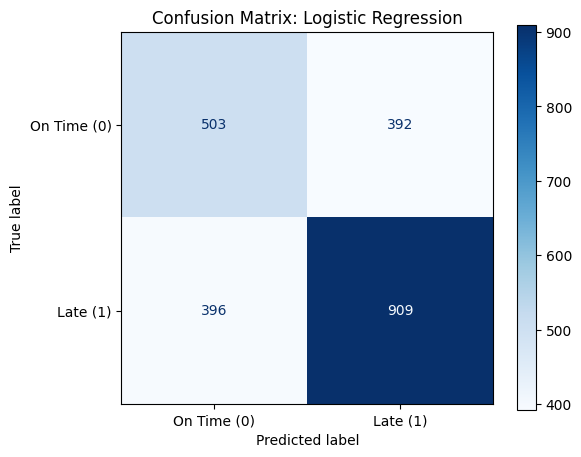

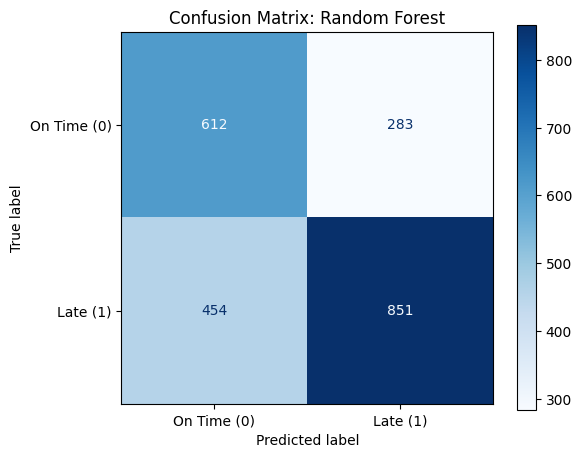

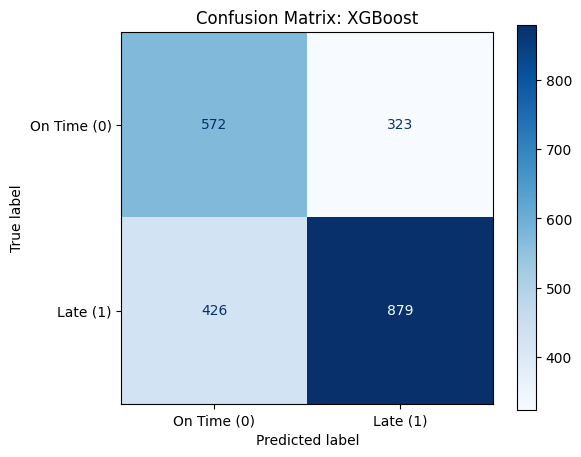

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Plotting
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time (0)', 'Late (1)'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix: {name}')
    plt.grid(False)
    plt.show()

#Step 11: Comparative Visualization of Model Performance

/tmp/ipykernel_521/2943437757.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


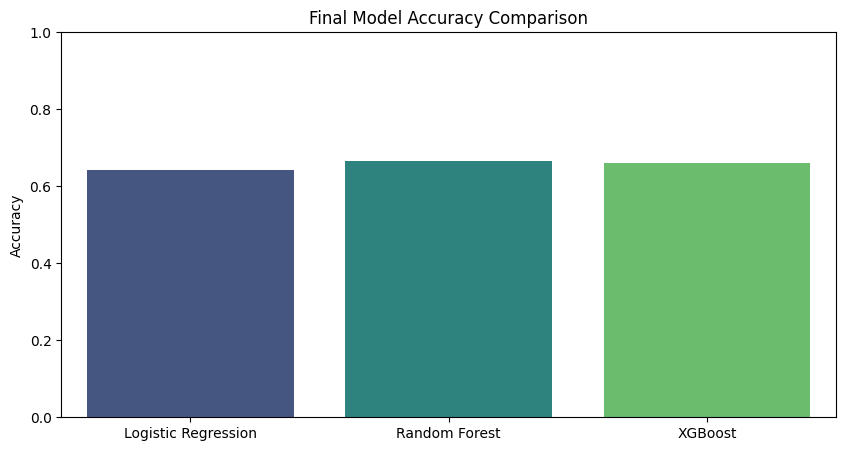

In [58]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Final Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()